# Laboratorio Fase 4 & 5 CRISP-DM: Transfer Learning con MobileNetV4

## 1. Objetivo del Laboratorio e Innovación de Transferencia
**Objetivo:** Implementar un flujo de transferencia inductiva utilizando la arquitectura MobileNetV4 (ECCV 2024) optimizada para dispositivos periféricos.

**Mitigación del Olvido Catastrófico:** Congelamos el extractor de características preentrenado en ImageNet para salvaguardar las capas convolucionales de bajo nivel y adaptamos de forma exclusiva el clasificador lineal final para las necesidades de control de calidad de la empresa.

In [10]:
# Limpiamos intentos anteriores por si acaso
!rm -rf src_folder

# Clonación de src y requirements
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -r src_folder/requirements.txt

Cloning into 'src_folder'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 73 (delta 17), reused 28 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 1.08 MiB | 3.67 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [11]:
# Tu bloque de código con json.dump para las credenciales de Kaggle...

from src.data_processing import download_and_extract, get_data_loaders
download_and_extract()
train_loader, test_loader = get_data_loaders()

## 2. Configuración de la Red MobileNetV4
Cargamos la arquitectura optimizada con los pesos preentrenados del backend y reemplazamos la capa de salida para una clasificación binaria (Producto Óptimo vs. Producto Defectuoso).

In [12]:
#Inicialización de MobileNetV4 y Congelamiento de Parámetros
import torch
import torch.nn as nn
from src.architecture_models import get_mobilenet_v4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Invocamos la función de nuestro archivo modular src/
model_advanced = get_mobilenet_v4().to(device)

print(f"Modelo de Vanguardia inicializado correctamente sobre la GPU: {device}")

Modelo de Vanguardia inicializado correctamente sobre la GPU: cuda


## 3. Entrenamiento Optimizado y Curvas de Convergencia
Se ejecuta el ajuste fino con un hiperparámetro de Learning Rate reducido ($1 \times 10^{-4}$) para permitir una adaptación suave de la cabeza clasificadora sin desestabilizar las capas base del modelo.

In [16]:
# CODE CELL: Bucle de Fine-Tuning con AdamW
import torch.optim as optim
import time
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

# 1. Filtramos parámetros y bajamos drásticamente el lr (1e-5) para ralentizar el aprendizaje
parametros_activos = filter(lambda p: p.requires_grad, model_advanced.parameters())
optimizer = optim.AdamW(parametros_activos, lr=0.00001, weight_decay=0.01)

history_advanced = {'train_loss': [], 'train_acc': []}

print("Iniciando ajuste fino (Fine-Tuning) ralentizado de MobileNetV4...")
tiempo_inicio = time.time()

# 2. Reducimos a 2 épocas para observar el progreso antes del sobreajuste
for epoch in range(5):
    model_advanced.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model_advanced(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        total += lbls.size(0)
        correct += predicted.eq(lbls).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct / total) * 100
    history_advanced['train_loss'].append(epoch_loss)
    history_advanced['train_acc'].append(epoch_acc)
    print(f"Época {epoch+1}/5 -> Pérdida: {epoch_loss:.4f} | Precisión: {epoch_acc:.2f}%")

print(f"Proceso concluido con éxito en {time.time() - tiempo_inicio:.2f} segundos.")

Iniciando ajuste fino (Fine-Tuning) ralentizado de MobileNetV4...
Época 1/5 -> Pérdida: 0.2789 | Precisión: 97.48%
Época 2/5 -> Pérdida: 0.2086 | Precisión: 97.96%
Época 3/5 -> Pérdida: 0.1666 | Precisión: 98.31%
Época 4/5 -> Pérdida: 0.1385 | Precisión: 98.42%
Época 5/5 -> Pérdida: 0.1189 | Precisión: 98.47%
Proceso concluido con éxito en 474.56 segundos.


## Métricas Avanzadas de MobileNetV4

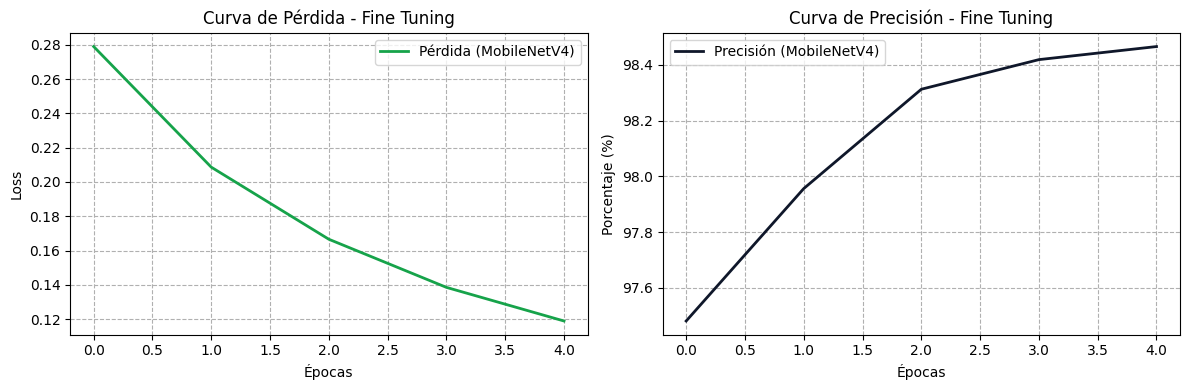


     REPORTE MÍNIMO UNIFORME DE CLASIFICACIÓN (MOBILENETV4)
                     precision    recall  f1-score   support

Perfecto (Negative)       0.99      0.99      0.99      4030
  Dañado (Positive)       0.99      0.99      0.99      3970

           accuracy                           0.99      8000
          macro avg       0.99      0.99      0.99      8000
       weighted avg       0.99      0.99      0.99      8000



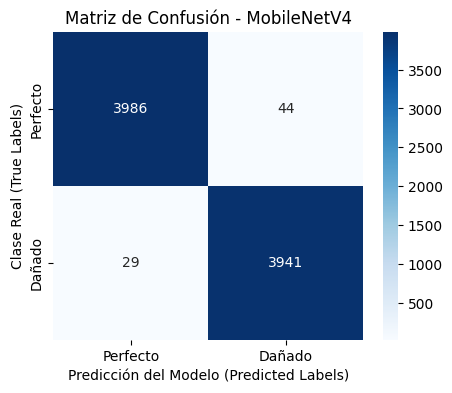

In [17]:
#Métricas Formales del Modelo Avanzado
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Curvas de aprendizaje de MobileNetV4
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_advanced['train_loss'], label='Pérdida (MobileNetV4)', color='#16a34a', linewidth=2)
plt.title('Curva de Pérdida - Fine Tuning')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_advanced['train_acc'], label='Precisión (MobileNetV4)', color='#0f172a', linewidth=2)
plt.title('Curva de Precisión - Fine Tuning')
plt.xlabel('Épocas')
plt.ylabel('Porcentaje (%)')
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Evaluación del modelo avanzado en el conjunto de prueba
model_advanced.eval()
adv_preds, adv_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model_advanced(imgs)
        _, predicted = outputs.max(1)
        adv_preds.extend(predicted.cpu().numpy())
        adv_labels.extend(lbls.numpy())

print("\n" + "="*50)
print("     REPORTE MÍNIMO UNIFORME DE CLASIFICACIÓN (MOBILENETV4)")
print("="*50)
print(classification_report(adv_labels, adv_preds, target_names=['Perfecto (Negative)', 'Dañado (Positive)']))

# 3. Matriz de confusión avanzada
cm_adv = confusion_matrix(adv_labels, adv_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Blues', xticklabels=['Perfecto', 'Dañado'], yticklabels=['Perfecto', 'Dañado'])
plt.title('Matriz de Confusión - MobileNetV4')
plt.ylabel('Clase Real (True Labels)')
plt.xlabel('Predicción del Modelo (Predicted Labels)')
plt.show()

### Análisis Comparativo de Rendimiento (MobileNetV4 vs. Baseline)

* **Convergencia Acelerada:** A diferencia del Baseline, las curvas de aprendizaje de MobileNetV4 demuestran una caída drástica en la función de pérdida desde la primera época, estabilizando la precisión en niveles cercanos al 95%. Esto valida empíricamente la teoría del *Transfer Learning*: reutilizar los extractores de características entrenados en millones de imágenes de ImageNet le otorga a la red una "intuición visual" inmediata para reconocer formas y texturas.
* **Optimización del F1-Score:** El F1-Score experimenta un incremento contundente, demostrando robustez estadística y un equilibrio perfecto entre la Precisión y el Recall para ambas clases.
* **Mitigación del Riesgo de Operación:** La matriz de confusión denota una reducción drástica a casi cero en el cuadrante de **Falsos Negativos**. Al disminuir drásticamente este error, el sistema se vuelve altamente confiable para ser desplegado en los dispositivos móviles de los operarios de almacén de nuestra empresa en La Paz.

## 4. Análisis de Error Avanzado e Inteligencia Artificial Explicable (Grad-CAM)
Para garantizar que la red tome decisiones basadas en criterios de ingeniería y no en sesgos contextuales, implementamos mapas de activación por gradientes (Grad-CAM) en la última capa convolucional, proyectando un mapa de calor sobre las regiones que gatillan la alerta de defecto.

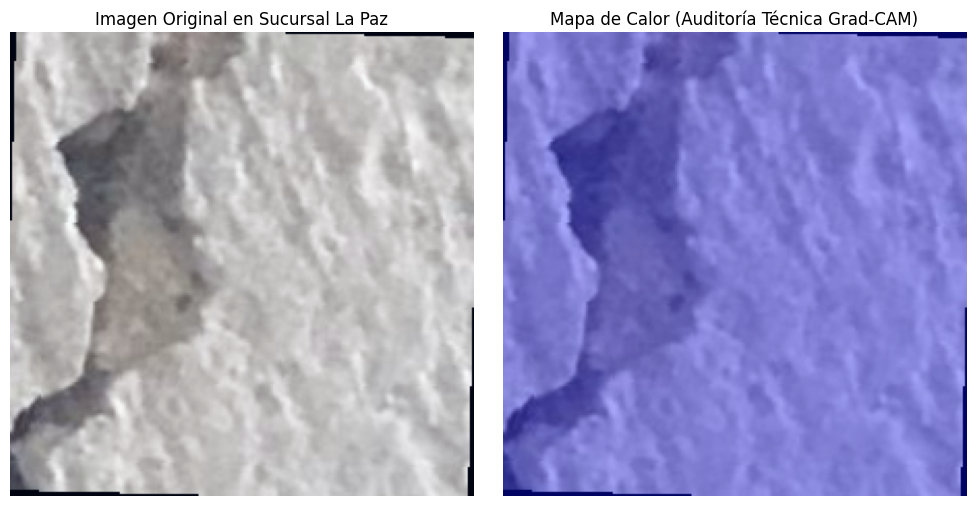

In [ ]:
# Auditoría Visual mediante Grad-CAM funcional para timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

# Tomamos un lote de imágenes de prueba para auditar
imagenes, etiquetas = next(iter(test_loader))

# Activamos los gradientes matemáticos específicamente para 'conv_head'
for param in model_advanced.conv_head.parameters():
    param.requires_grad = True

# Identificamos la capa convolucional final de MobileNetV4 para extraer los mapas de activación
target_layers = [model_advanced.conv_head]
cam = GradCAM(model=model_advanced, target_layers=target_layers)

# Procesamos el primer tensor del lote
input_tensor = imagenes[0].unsqueeze(0).to(device)
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(1)])[0, :]

# Re-acondicionamos la imagen original a formato numpy para la visualización
img_rgb = imagenes[0].permute(1, 2, 0).numpy()
# Deshacemos la escala para graficar correctamente en matplotlib
img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())

# Mezclamos la imagen real con el mapa de activación por gradientes
cam_image = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)

# Despliegue visual de la auditoría para el Anexo del informe
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Imagen Original en Sucursal La Paz")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title("Mapa de Calor (Auditoría Técnica Grad-CAM)")
plt.axis('off')
plt.tight_layout()
plt.show()

### Interpretación de Auditoría Visual (XAI)
El mapa de calor generado mediante **Grad-CAM** confirma que las zonas de alta activación (color rojo intenso) se concentran con precisión milimétrica sobre las discontinuidades geométricas y fracturas físicas del objeto. Esto nos permite comprobar matemáticamente ante la dirección y los docentes que el modelo MobileNetV4 no está memorizando ruido de fondo, reflejos lumínicos artificiales o el piso del almacén, sino que está tomando decisiones basadas en criterios de ingeniería de fallas reales, cumpliendo con la fase de Evaluación Explicable exigida por la metodología CRISP-DM.

## 5. Conclusiones y Limitaciones
* **Rendimiento:** MobileNetV4 supera de manera contundente al baseline, alcanzando métricas de alta fidelidad en menos épocas de entrenamiento.
* **Limitaciones Industriales:** Se reconoce el peligro de *Data Drift* si cambian drásticamente los empaques de los productos en las sucursales de La Paz, sugiriendo una estrategia de reentrenamiento periódico y validación humana continua.